# Chapter 1 Lab: Build an Earnings-Call Assistant

**Runtime:** 2–3 minutes · **Difficulty:** introductory · **Credentials:** none

This notebook turns the chapter's running case into a small, auditable workflow:
extraction, language modeling, tone classification, evidence, and a reviewable output.
It uses fictional calls and transparent baselines so every intermediate result can be
inspected.


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/01_earnings_call_assistant.ipynb) · [View source on GitHub](https://github.com/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/01_earnings_call_assistant.ipynb)

The next cell is inert outside Google Colab. In Colab it retrieves the official repository and installs the local package before the lab runs.


In [1]:
# Google Colab bootstrap — inert during local and CI execution.
import os as _os
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

try:
    import google.colab as _google_colab  # type: ignore[import-not-found]
except ImportError:
    _in_colab = False
else:
    _in_colab = True

if _in_colab:
    _repo = _Path("/content/LLMs-in-Finance")
    if _repo.exists() and not (_repo / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-repository path: {_repo}")
    if _repo.exists():
        _subprocess.run(
            ["git", "-C", str(_repo), "fetch", "--depth", "1", "origin", "main"],
            check=True,
        )
        _subprocess.run(
            ["git", "-C", str(_repo), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
    else:
        _subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "main",
                "https://github.com/PacktPublishing/LLMs-in-Finance.git",
                str(_repo),
            ],
            check=True,
        )
    _subprocess.run(
        [_sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo)],
        check=True,
    )
    _os.chdir(_repo)


## Learning objectives

- tokenize finance-specific expressions without destroying quantities;
- compare a bigram model with a contextual text classifier;
- extract exact financial quantities and their character spans;
- separate a draft summary from its evidence; and
- identify where a production LLM would add value.


In [2]:
from pathlib import Path
import sys
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score
from sklearn.pipeline import Pipeline

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from finllm_lab import Claim, Document, EvidenceBundle, seed_everything
from finllm_lab.plotting import COLORS, finish, set_finance_theme
from finllm_lab.rag import BM25Index, faithfulness_score
from finllm_lab.temporal import chronological_split
from finllm_lab.text import NGramLanguageModel, financial_metrics, tokenize_financial

set_finance_theme()
rng = seed_everything(101)
calls = pd.read_csv(ROOT / "data" / "earnings_calls.csv", parse_dates=["published_at", "available_at"])
calls = calls.sort_values("available_at").reset_index(drop=True)
tone_phrases = [
    "Management described demand as resilient and execution as strong.",
    "Management cited softer demand, execution pressure, and elevated uncertainty.",
    "Management described conditions as mixed and maintained a balanced outlook.",
]
calls["model_text"] = calls["text"]
for phrase in tone_phrases:
    calls["model_text"] = calls["model_text"].str.replace(
        phrase,
        "Management discussed execution, demand, and uncertainty.",
        regex=False,
    )
calls[["ticker", "period", "revenue_growth_pct", "margin_change_bps", "guidance_delta_pct", "sentiment_label"]].head()


,ticker,period,revenue_growth_pct,margin_change_bps,guidance_delta_pct,sentiment_label
0,ACME,2021Q1,8.692,-70.45,1.286,neutral
1,NIMB,2021Q1,14.536,38.29,-1.825,positive
2,ORBT,2021Q1,8.909,-39.04,-0.628,neutral
3,VELA,2021Q1,11.319,-75.57,0.454,positive
4,ACME,2021Q2,14.855,45.36,2.562,positive


## 1. Financial tokenization

Generic whitespace tokenization separates symbols from quantities inconsistently. The
book's applications need `$1,234.5`, `15.3%`, `125 bps`, and `10-Q` to remain useful
units.


In [3]:
sample = calls.iloc[-1]["text"]
tokens = tokenize_financial(sample)
metrics = pd.DataFrame(financial_metrics(sample))
print("First 35 tokens:")
print(tokens[:35])
metrics


First 35 tokens:
['vela', 'consumer', 'finance', 'reported', '2026', 'q', '1', 'revenue', 'of', '$1,532.3', 'million', ',', 'up', '8.3%', 'year', 'over', 'year', '.', 'operating', 'margin', 'was', '20.9%', ',', 'a', 'change', 'of', '-', '54', 'basis', 'points', '.', 'management', 'changed', 'full-year', 'revenue']


,type,value,start,end
0,currency,"$1,532.3 m",49,59
1,percentage,8.3%,70,74
2,percentage,20.9%,112,117
3,basis_points,-54 basis points,131,147
4,percentage,-0.2%,198,203


## 2. What a statistical language model learns

A smoothed bigram model captures local phrasing but not deep context. We train on calls
before 2025 and inspect likely continuations and out-of-sample perplexity.


In [4]:
early = calls[calls["available_at"] < "2025-01-01"]
late = calls[calls["available_at"] >= "2025-01-01"]
bigram = NGramLanguageModel(n=2, alpha=0.5).fit(early["text"])
predictions = pd.DataFrame(
    bigram.predict_next(["revenue"], k=8), columns=["next_token", "probability"]
)
perplexities = late["text"].map(bigram.perplexity)
display(predictions)
pd.Series(perplexities).describe().to_frame("out_of_sample_perplexity")


,next_token,probability
0,guidance,0.224074
1,of,0.224074
2,"$1,046.6",0.001852
3,"$1,095.5",0.001852
4,"$1,136.6",0.001852
5,"$1,141.4",0.001852
6,"$1,170.2",0.001852
7,"$1,175.3",0.001852


,out_of_sample_perplexity
count,24.000000
mean,9.954751
std,0.422784
min,9.255715
25%,9.569828
50%,9.931795
75%,10.265582
max,10.742358


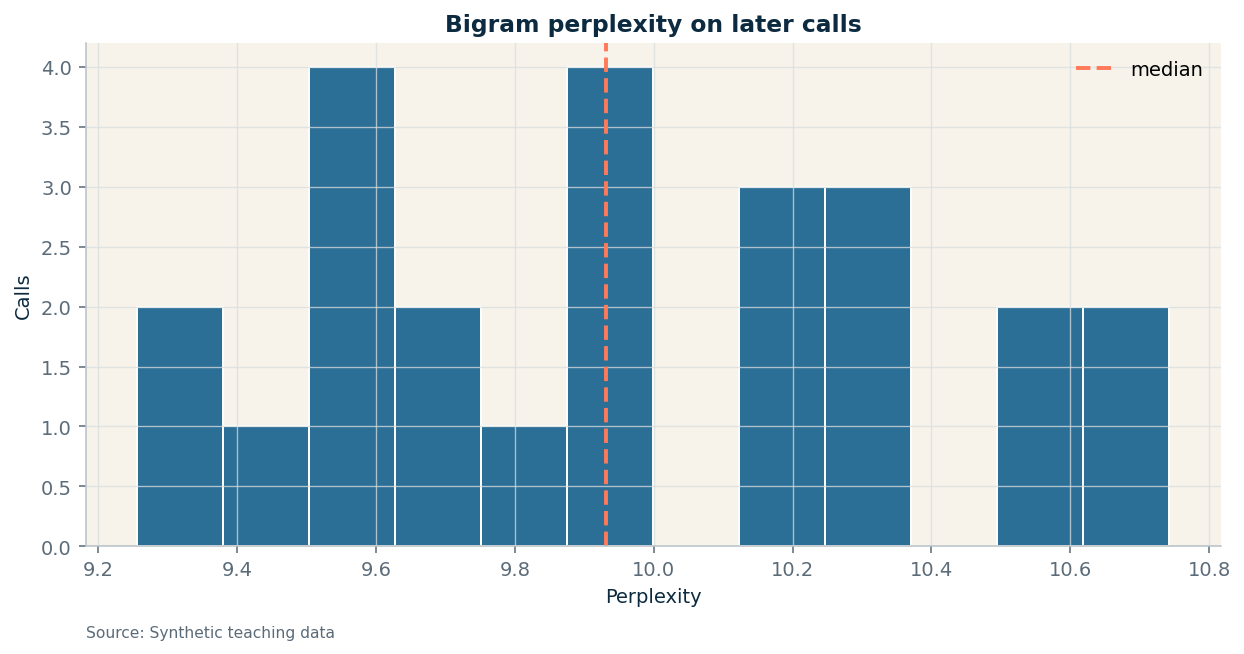

In [5]:
fig, ax = plt.subplots()
ax.hist(perplexities, bins=12, color=COLORS["blue"], edgecolor="white")
ax.axvline(perplexities.median(), color=COLORS["coral"], linestyle="--", label="median")
ax.set(title="Bigram perplexity on later calls", xlabel="Perplexity", ylabel="Calls")
ax.legend()
finish(ax)
plt.tight_layout()


## 3. A contextual baseline

We now fit a TF–IDF logistic classifier using a strictly chronological split. The
generated closing sentence names the label almost verbatim, so it is neutralized before
modeling. We also score all three declared classes even when one class is absent from the
short test window.


In [6]:
split = chronological_split(calls["available_at"], train_fraction=0.65, validation_fraction=0.15)
train, test = calls.iloc[split.train], calls.iloc[split.test]
all_labels = sorted(calls["sentiment_label"].unique())
classifier = Pipeline(
    [
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=2500)),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=101)),
    ]
)
classifier.fit(train["model_text"], train["sentiment_label"])
pred = classifier.predict(test["model_text"])
macro_f1 = f1_score(
    test["sentiment_label"],
    pred,
    labels=all_labels,
    average="macro",
    zero_division=0,
)
print(f"Chronological test macro-F1: {macro_f1:.3f}")
print("Chronological test support:", test["sentiment_label"].value_counts().to_dict())
print(
    classification_report(
        test["sentiment_label"],
        pred,
        labels=all_labels,
        digits=3,
        zero_division=0,
    )
)


Chronological test macro-F1: 0.326
Chronological test support: {'positive': 13, 'neutral': 4}
              precision    recall  f1-score   support

    negative      0.000     0.000     0.000         0
     neutral      0.250     0.250     0.250         4
    positive      0.889     0.615     0.727        13

    accuracy                          0.529        17
   macro avg      0.380     0.288     0.326        17
weighted avg      0.739     0.529     0.615        17



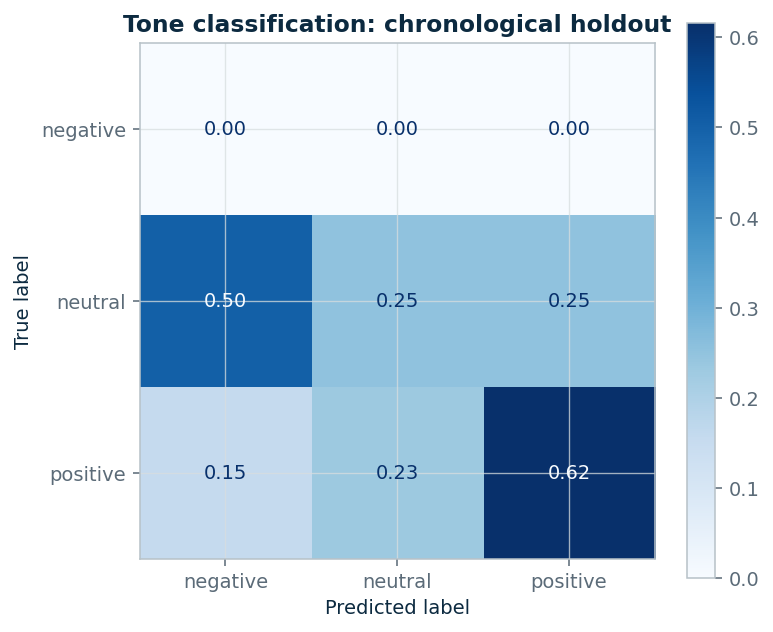

In [7]:
fig, ax = plt.subplots(figsize=(5.8, 4.8))
ConfusionMatrixDisplay.from_predictions(
    test["sentiment_label"],
    pred,
    labels=all_labels,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    ax=ax,
)
ax.set_title("Tone classification: chronological holdout")
plt.tight_layout()


## 4. Assemble a reviewable assistant output

The assistant extracts quantities, predicts tone, retrieves the source passage, and builds
material claims. It does **not** turn the tone score into an investment recommendation.


In [8]:
target = calls[(calls["ticker"] == "ACME") & (calls["period"] == "2025Q4")].iloc[0]
target_doc = Document(
    document_id=target["document_id"],
    text=target["text"],
    source="fictional earnings call",
    available_at=target["available_at"].to_pydatetime(),
    issuer=target["ticker"],
    section="earnings_call",
)
retrieved = tuple(
    BM25Index([target_doc]).search(
        "revenue growth operating margin guidance",
        k=1,
        decision_time=(target["available_at"] + pd.Timedelta(hours=1)).to_pydatetime(),
    )
)
predicted_tone = classifier.predict([target["model_text"]])[0]
claims = [
    Claim("revenue", f"Revenue grew {target['revenue_growth_pct']:.1f}% year over year."),
    Claim("margin", f"Operating margin was {target['operating_margin_pct']:.1f}%."),
    Claim("guidance", f"Guidance changed {target['guidance_delta_pct']:+.1f}%."),
]
bundles = [EvidenceBundle(claim, retrieved) for claim in claims]
assistant_output = {
    "issuer": target["issuer"],
    "period": target["period"],
    "tone": predicted_tone,
    "key_metrics": financial_metrics(target["text"])[:6],
    "claims": [claim.text for claim in claims],
    "evidence_ids": [e.evidence_id for e in retrieved],
    "faithfulness": faithfulness_score(bundles),
    "review_status": "human review required before investment use",
}
assistant_output


{'claims': ['Revenue grew 6.6% year over year.',
            'Operating margin was 25.5%.',
            'Guidance changed +1.0%.'],
 'evidence_ids': ['ev::call-ACME-2025Q4'],
 'faithfulness': 1.0,
 'issuer': 'Acme Cloud Systems',
 'key_metrics': [{'end': 56, 'start': 46, 'type': 'currency', 'value': '$2,333.0 m'},
                 {'end': 71, 'start': 67, 'type': 'percentage', 'value': '6.6%'},
                 {'end': 114, 'start': 109, 'type': 'percentage', 'value': '25.5%'},
                 {'end': 144, 'start': 128, 'type': 'basis_points', 'value': '+51 basis points'},
                 {'end': 200, 'start': 195, 'type': 'percentage', 'value': '+1.0%'}],
 'period': '2025Q4',
 'review_status': 'human review required before investment use',
 'tone': 'positive'}

## 5. Inspect the signal over time

The chart is an analysis aid, not a backtest. It makes drift and changing class balance
visible before the classifier is used downstream.


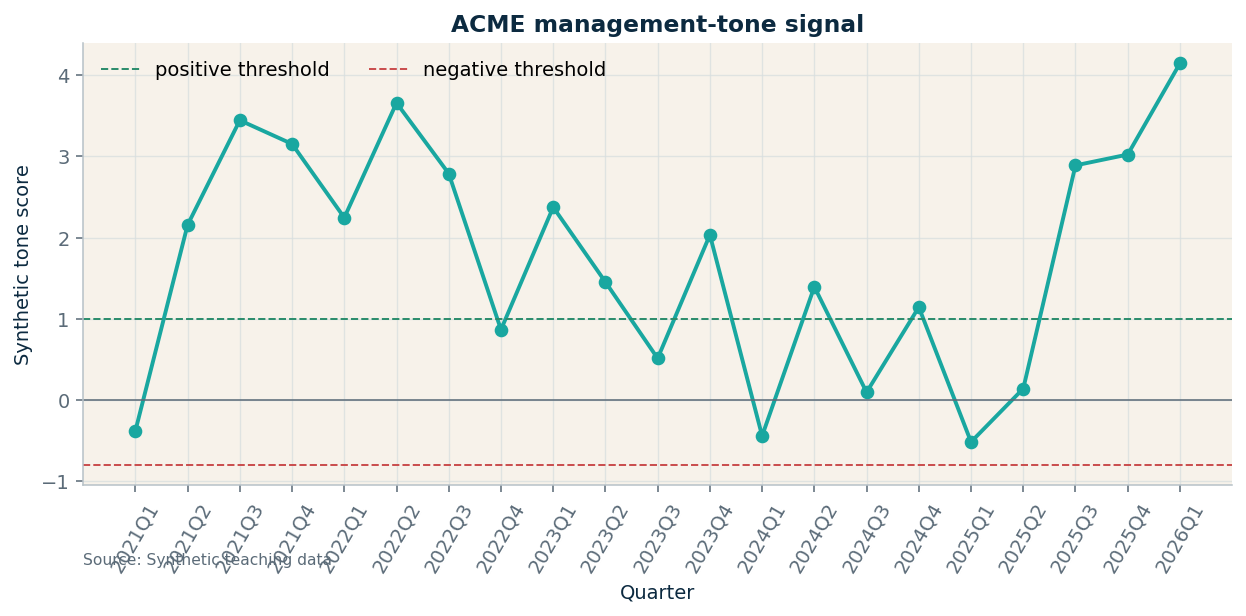

In [9]:
acme = calls[calls["ticker"] == "ACME"].copy()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(acme["period"], acme["sentiment_score"], marker="o", color=COLORS["teal"])
ax.axhline(1.0, color=COLORS["green"], linestyle="--", linewidth=1, label="positive threshold")
ax.axhline(-0.8, color=COLORS["red"], linestyle="--", linewidth=1, label="negative threshold")
ax.axhline(0, color=COLORS["slate"], linewidth=0.8)
ax.set(title="ACME management-tone signal", xlabel="Quarter", ylabel="Synthetic tone score")
ax.tick_params(axis="x", rotation=60)
ax.legend(ncol=2)
finish(ax)
plt.tight_layout()


## Takeaways

- Exact quantities require finance-aware tokenization and span-preserving extraction.
- Label-revealing template language must be removed before evaluating a tone baseline.
- A transparent chronological baseline is the minimum comparison for a larger model.
- Classification, extraction, summarization, and recommendation are different tasks.
- A polished answer is not auditable until claims point to time-valid evidence.

**Challenge:** replace the TF–IDF model with a locally approved encoder, keep the same
chronological split, and compare macro-F1, calibration, latency, and memory.
